# Pipeline Completo — Garantia de Escoamento com 3W Dataset

**TCC — Engenharia Mecatrônica, UnB**

Este notebook apresenta, de forma integrada, todas as etapas do pipeline de Machine Learning
desenvolvido para classificar eventos de garantia de escoamento em poços de petróleo.

| Etapa | Conteúdo |
|-------|----------|
| 1 | Problema e Dataset |
| 2 | Análise Exploratória |
| 3 | Engenharia de Features |
| 4 | Estratégia de Rotulagem |
| 5 | Validação — GroupKFold e Nested CV |
| 6 | Modelos Treinados |
| 7 | Resultados e Métricas |
| 8 | Interpretabilidade — XAI |
| 9 | Conclusões |

> **Nota:** células marcadas com ⏳ carregam resultados pré-computados (treino/SHAP).
> Todo o restante roda em segundos.

In [1]:
import sys
sys.path.insert(0, "..")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display
from pathlib import Path

from config import (
    WINDOW_CLASSES, FAULT_CLASSES, FEATURES_WINDOW_PATH, FEATURES_DATA_PATH,
    FIGURES_DIR, MODELS_DIR, METRICS_DIR,
)

FIG_EDA  = FIGURES_DIR / "eda"
FIG_CM   = FIGURES_DIR / "confusion_matrix"
FIG_SHAP = FIGURES_DIR / "shap"

print("Ambiente carregado.")

Ambiente carregado.


---
## 1. Problema e Dataset

### 1.1 Contexto

**Garantia de escoamento** é a área da engenharia de petróleo responsável por assegurar
que o fluido produzido chegue à superfície sem obstruções. Em poços subseas (submarinos),
os principais riscos são hidratos de gás, incrustações, golfadas severas e falhas de válvulas.

### 1.2 Dataset 3W (Petrobras)

O **3W Dataset** contém séries temporais reais e sintéticas de 8 sensores em poços de petróleo.

| Sensor | Descrição | Posição |
|--------|-----------|---------|
| P-PDG | Pressão no sensor de fundo | Fundo do poço |
| T-PDG | Temperatura no sensor de fundo | Fundo do poço |
| P-TPT | Pressão no topo da árvore de natal | Superfície/Topo |
| T-TPT | Temperatura no topo da árvore de natal | Superfície/Topo |
| P-MON-CKP | Pressão no manifold | A montante do choke |
| T-JUS-CKP | Temperatura a jusante da válvula choke | A jusante do choke |
| P-JUS-CKGL | Pressão a jusante do choke de gás lift | Linha de gás lift |
| QGL | Vazão de gás lift | — |

In [2]:
print("Classes do 3W Dataset — Abordagem 2 (17 classes):")
print(f"{'Código':>6}  {'Nome'}")
print("-" * 50)
for c, name in sorted(WINDOW_CLASSES.items()):
    print(f"{c:>6}  {name}")

Classes do 3W Dataset — Abordagem 2 (17 classes):
Código  Nome
--------------------------------------------------
     0  Normal
     1  BSW (Ativo)
     2  DHSV (Ativo)
     3  Golfadas (Ativo)
     4  Inst. Fluxo (Ativo)
     5  Prod. Rapida (Ativo)
     6  PCK Restrict. (Ativo)
     7  PCK Incrust. (Ativo)
     8  Hidrato Prod. (Ativo)
     9  Hidrato Serv. (Ativo)
   101  BSW (Trans.)
   102  DHSV (Trans.)
   103  Golfadas (Trans.)
   104  Inst. Fluxo (Trans.)
   105  Prod. Rapida (Trans.)
   106  PCK Restrict. (Trans.)
   107  PCK Incrust. (Trans.)
   108  Hidrato Prod. (Trans.)
   109  Hidrato Serv. (Trans.)


---
## 2. Análise Exploratória

### 2.1 Dados limpos

Após limpeza: forward-fill limitado a 60 s, descarte de instâncias sem sensores críticos,
e normalização Z-score **por instância** (cada poço tem sua própria média e desvio padrão —
evita que o nível absoluto de pressão vaze como feature discriminativa).

In [3]:
from config import CLEANED_DATA_PATH

df_clean = pd.read_parquet(CLEANED_DATA_PATH)
print(f"Dimensões:         {df_clean.shape}")
print(f"Instâncias únicas: {df_clean['instance_id'].nunique():,}")
print(f"Classes:           {sorted(df_clean['fault_class'].unique().tolist())}")
print()
df_clean.head(3)

Dimensões:         (71219079, 33)
Instâncias únicas: 1,409
Classes:           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,class,state,instance_id,fault_class,fault_label,source_type
0,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.64463,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
1,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63828,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL
2,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,84.63194,NaN,0.0,119.0781,<NA>,<NA>,WELL-00001_20170201010207,0,Normal,WELL


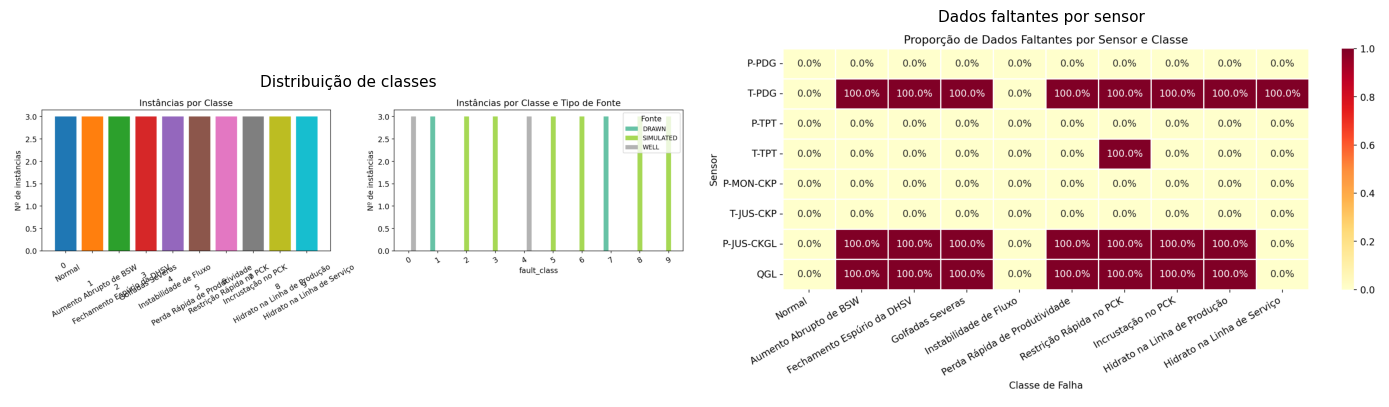

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(mpimg.imread(str(FIG_EDA / "distribuicao_classes.png")))
axes[0].set_title("Distribuição de classes", fontsize=11)
axes[0].axis("off")
axes[1].imshow(mpimg.imread(str(FIG_EDA / "dados_faltantes.png")))
axes[1].set_title("Dados faltantes por sensor", fontsize=11)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 2.2 Séries temporais por classe

Abaixo, exemplos dos 8 sensores durante 4 eventos diferentes.
Os padrões visuais revelam por que alguns eventos são difíceis de distinguir em tempo real.

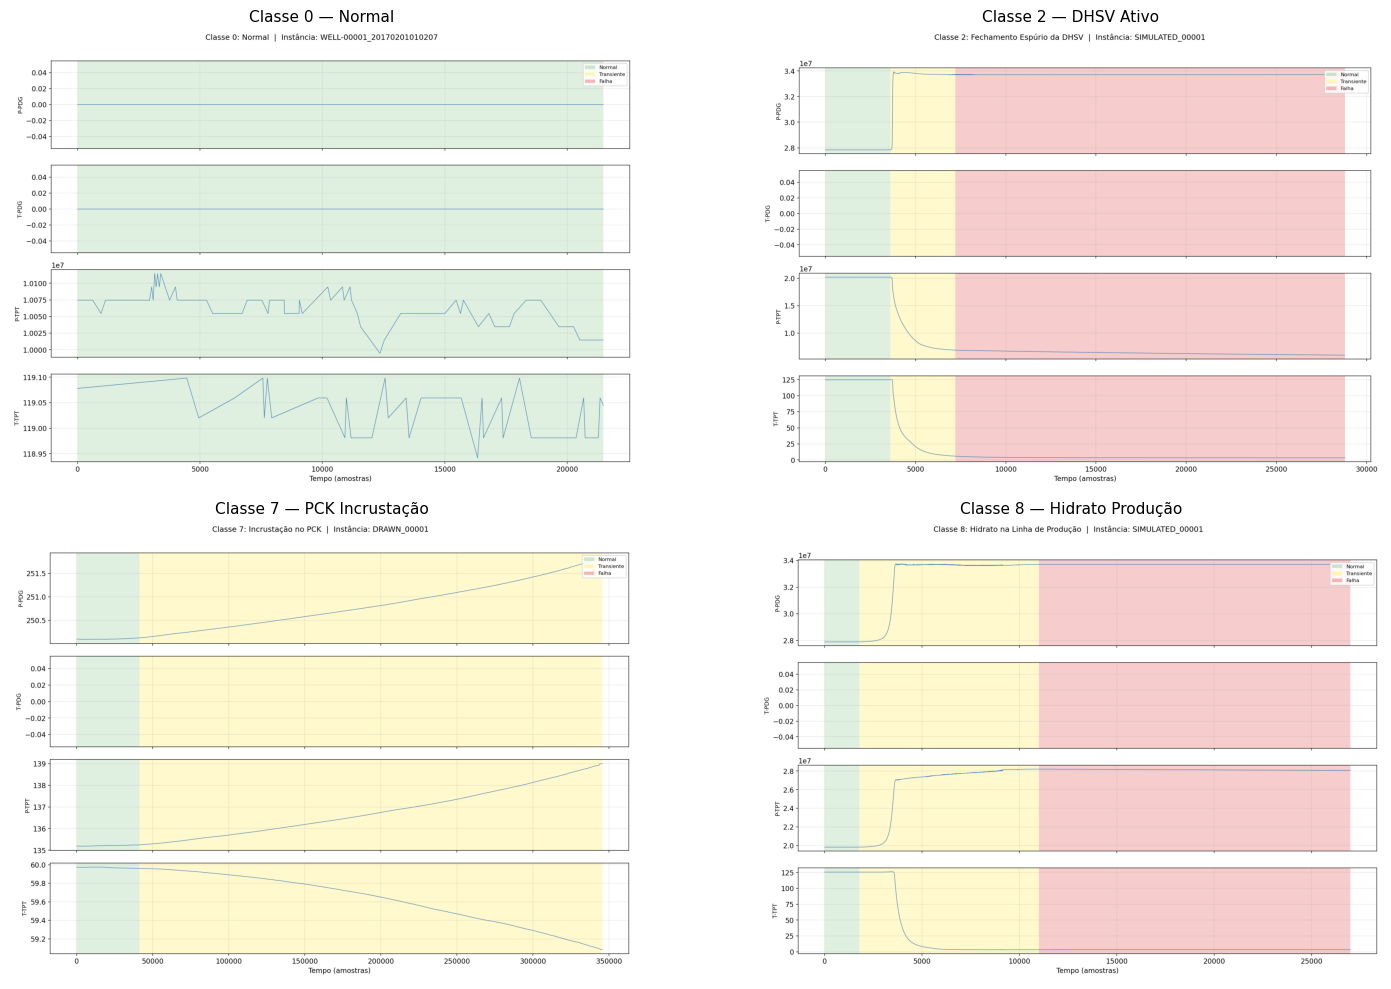

In [5]:
classes_exibir = [0, 2, 7, 8]  # Normal, DHSV, PCK Incrustação, Hidrato Produção
nomes = {0: "Normal", 2: "DHSV Ativo", 7: "PCK Incrustação", 8: "Hidrato Produção"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ts_dir = FIGURES_DIR / "time_series"
for ax, c in zip(axes.flat, classes_exibir):
    p = ts_dir / f"serie_temporal_classe_{c}.png"
    if not p.exists():
        p = FIG_EDA / f"serie_temporal_classe_{c}.png"
    if p.exists():
        ax.imshow(mpimg.imread(str(p)))
    ax.set_title(f"Classe {c} — {nomes[c]}", fontsize=11)
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 3. Engenharia de Features — Janela Deslizante

Para cada janela de **300 segundos** (passo de 60 s), extraímos 11 estatísticas de cada
um dos 8 sensores → **88 features** por janela.

| Estatística | O que mede |
|-------------|-----------|
| `mean`, `median` | Nível central |
| `std`, `iqr` | Variabilidade (std sensível a picos; iqr robusto) |
| `min`, `max` | Extremos |
| `skewness` | Assimetria da distribuição |
| `kurtosis` | Peso das caudas |
| `diff1_std` | Desvio padrão da 1ª derivada — velocidade de variação |
| `diff2_std` | Desvio padrão da 2ª derivada — aceleração de variação |
| `max_zscore` | Magnitude do pico mais extremo |

> **Insight:** `diff1_std` e `diff2_std` são essenciais para detectar **estados transientes**
> (ex: DHSV começando a fechar) — o evento se manifesta na *taxa de mudança*, não no nível.

In [6]:
df_feat = pd.read_parquet(FEATURES_WINDOW_PATH)
META_COLS = ["instance_id", "fault_class", "window_label", "source_type", "window_start"]
feature_cols = [c for c in df_feat.columns if c not in META_COLS]

print(f"Janelas totais : {len(df_feat):,}")
print(f"Features       : {len(feature_cols)}  (= 8 sensores × 11 estatísticas)")
print(f"Classes únicas : {sorted(df_feat['window_label'].unique().tolist())}")
print()
print("Exemplos de nomes de features:")
for f in feature_cols[:11]:
    print(f"  {f}")
print(f"  ...  (total {len(feature_cols)})")

Janelas totais : 449,397
Features       : 88  (= 8 sensores × 11 estatísticas)
Classes únicas : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 101, 102, 105, 106, 107, 108, 109]

Exemplos de nomes de features:
  P-PDG_mean
  P-PDG_std
  P-PDG_min
  P-PDG_max
  P-PDG_skewness
  P-PDG_kurtosis
  P-PDG_median
  P-PDG_iqr
  P-PDG_diff1_std
  P-PDG_diff2_std
  P-PDG_max_zscore
  ...  (total 88)


---
## 4. Estratégia de Rotulagem — Duas Abordagens

| | Abordagem 1 | Abordagem 2 |
|-|-------------|-------------|
| **Label** | Classe do poço inteiro | Estado operacional da janela |
| **Classes** | 10 | 17 |
| **Pergunta** | "Que falha este poço teve?" | "O que está acontecendo *agora*?" |
| **Uso** | Diagnóstico retroativo | Monitoramento em tempo real |

A Abordagem 2 inclui estados **transientes** (ex: classe 102 = DHSV *começando* a fechar),
permitindo detecção preventiva antes do evento se tornar ativo.

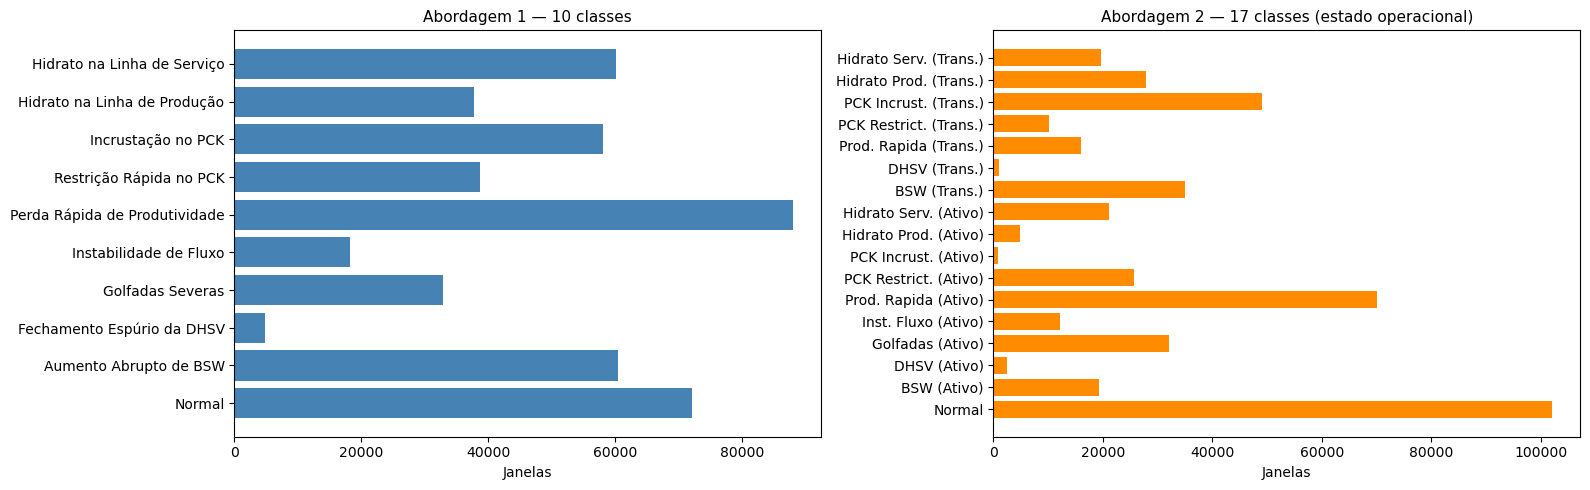

Abordagem 1: 471,477 janelas | menor classe: 4,767 | maior: 88,079
Abordagem 2: 449,397 janelas | menor classe: 914 | maior: 102,040


In [7]:
df_a1 = pd.read_parquet(FEATURES_DATA_PATH)
df_a2 = pd.read_parquet(FEATURES_WINDOW_PATH)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cnt1 = df_a1["fault_class"].value_counts().sort_index()
labels1 = [FAULT_CLASSES.get(c, str(c)) for c in cnt1.index]
axes[0].barh(labels1, cnt1.values, color="steelblue")
axes[0].set_title("Abordagem 1 — 10 classes", fontsize=11)
axes[0].set_xlabel("Janelas")

cnt2 = df_a2["window_label"].value_counts().sort_index()
labels2 = [WINDOW_CLASSES.get(c, str(c)) for c in cnt2.index]
axes[1].barh(labels2, cnt2.values, color="darkorange")
axes[1].set_title("Abordagem 2 — 17 classes (estado operacional)", fontsize=11)
axes[1].set_xlabel("Janelas")

plt.tight_layout()
plt.show()

print(f"Abordagem 1: {len(df_a1):,} janelas | menor classe: {cnt1.min():,} | maior: {cnt1.max():,}")
print(f"Abordagem 2: {len(df_a2):,} janelas | menor classe: {cnt2.min():,} | maior: {cnt2.max():,}")

---
## 5. Estratégia de Validação

### 5.1 GroupKFold — sem data leakage por poço

O risco principal em séries temporais de poços é o **data leakage**: janelas do mesmo poço
aparecem no treino e no teste, e o modelo memoriza o comportamento daquele poço.

Solução: `GroupKFold(n_splits=5, groups=instance_id)` — todos as janelas de um mesmo poço
ficam *inteiramente* num único fold (treino *ou* teste, nunca os dois).

### 5.2 Nested CV — validação da seleção de hiperparâmetros

| | Flat CV | Nested CV |
|-|---------|-----------|
| **Estrutura** | 1 loop (5 folds) | 2 loops (externo 5×, interno 3×) |
| **Hiperparâmetros vistos nos dados de teste?** | ✗ Sim (viés) | ✓ Não |
| **Fits totais** | 100 | 300 |
| **Resultado** | F1 = 0,8827 | F1 = 0,8732 ± 0,0202 |
| **Viés medido** | — | −0,95% |

In [8]:
with open(METRICS_DIR / "rf_nested_cv_results.json") as f:
    nested = json.load(f)

print("Nested CV — Random Forest (Abordagem 2)")
print(f"{'Fold':>5}  {'F1-macro externo':>18}")
print("-" * 26)
for i, s in enumerate(nested["outer_fold_scores"], 1):
    print(f"{i:>5}  {s:>18.4f}")
print("-" * 26)
print(f"{'Média':>5}  {nested['mean_f1_macro']:>18.4f}")
print(f"{'±std':>5}  {nested['std_f1_macro']:>18.4f}")
print()
print(f"Flat CV (referência): 0.8827")
print(f"Viés de seleção:      {nested['delta_vs_flat_cv']:+.4f}  ({abs(nested['delta_vs_flat_cv'])*100:.2f}%)")
print("Conclusão: viés pequeno (~1%) — metodologia validada.")

Nested CV — Random Forest (Abordagem 2)
 Fold    F1-macro externo
--------------------------
    1              0.8883
    2              0.8415
    3              0.8743
    4              0.8624
    5              0.8996
--------------------------
Média              0.8732
 ±std              0.0202

Flat CV (referência): 0.8827
Viés de seleção:      -0.0095  (0.95%)
Conclusão: viés pequeno (~1%) — metodologia validada.


---
## 6. Modelos Treinados

> ⏳ **Pré-computado:** treino realizado com `RandomizedSearchCV + GroupKFold(5)`.
> Para retreinar: `python scripts/train_window_class.py`

### Random Forest
Ensemble de 200 árvores independentes (*bagging*). Robusto, interpretável via MDI.
Limitação: paralelo por natureza — classes raras podem ser ignoradas.

### XGBoost
500 árvores construídas **sequencialmente** (*gradient boosting*). Cada árvore foca nos
erros das anteriores — essencial para detectar classes raras como a classe 7.

In [9]:
rf  = joblib.load(MODELS_DIR / "rf_window_class.joblib")
xgb_model = joblib.load(MODELS_DIR / "xgboost_window_class.joblib")

print("=== Random Forest ===")
print(f"  n_estimators:     {rf.n_estimators}")
print(f"  max_depth:        {rf.max_depth}  (None = árvores completas, profundidade ~42)")
print(f"  max_features:     {rf.max_features}")
print(f"  min_samples_leaf: {rf.min_samples_leaf}")
print(f"  class_weight:     {rf.class_weight}")

print()
print("=== XGBoost ===")
p = xgb_model.get_params()
for k in ["n_estimators", "max_depth", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"]:
    print(f"  {k:<20}: {p[k]}")

=== Random Forest ===
  n_estimators:     200
  max_depth:        None  (None = árvores completas, profundidade ~42)
  max_features:     sqrt
  min_samples_leaf: 2
  class_weight:     balanced

=== XGBoost ===
  n_estimators        : 500
  max_depth           : 4
  learning_rate       : 0.1
  subsample           : 0.8
  colsample_bytree    : 1.0
  min_child_weight    : 3


---
## 7. Resultados — Métricas e Avaliação

**F1-macro:** média do F1 de cada classe sem ponderação pelo tamanho.
Classes raras (914 janelas) pesam tanto quanto classes majoritárias (100k+ janelas).

In [10]:
with open(METRICS_DIR / "rf_window_class_metrics.json") as f:
    m_rf = json.load(f)
with open(METRICS_DIR / "xgboost_window_class_metrics.json") as f:
    m_xgb = json.load(f)

print(f"{'Métrica':<20} {'RF':>10} {'XGBoost':>10}")
print("-" * 42)
for metric in ["f1_macro", "f1_weighted", "accuracy"]:
    rf_v  = m_rf["metrics_concat_folds"][metric]
    xgb_v = m_xgb["metrics_concat_folds"][metric]
    print(f"{metric:<20} {rf_v:>10.4f} {xgb_v:>10.4f}")
print()

rows = []
for c_str, v in m_rf["per_class"].items():
    c = int(c_str)
    xgb_f1 = m_xgb["per_class"][c_str]["f1"]
    rows.append({"Classe": c, "Nome": v["name"], "RF F1": v["f1"],
                 "XGBoost F1": xgb_f1, "Δ (XGB−RF)": round(xgb_f1 - v["f1"], 4)})

df_res = pd.DataFrame(rows).set_index("Classe")
print("F1 por classe:")
print(df_res.to_string())

Métrica                      RF    XGBoost
------------------------------------------
f1_macro                 0.8716     0.9082
f1_weighted              0.9308     0.9361
accuracy                 0.9322     0.9364

F1 por classe:
                          Nome   RF F1  XGBoost F1  Δ (XGB−RF)
Classe                                                        
0                       Normal  0.9022      0.9145      0.0123
1                  BSW (Ativo)  0.9410      0.9389     -0.0021
2                 DHSV (Ativo)  0.9722      0.9729      0.0007
3             Golfadas (Ativo)  0.9641      0.9674      0.0033
4          Inst. Fluxo (Ativo)  0.9188      0.8988     -0.0200
5         Prod. Rapida (Ativo)  0.9789      0.9819      0.0030
6        PCK Restrict. (Ativo)  0.9904      0.9901     -0.0003
7         PCK Incrust. (Ativo)  0.0086      0.5712      0.5626
8        Hidrato Prod. (Ativo)  0.8548      0.8497     -0.0051
9        Hidrato Serv. (Ativo)  0.9909      0.9895     -0.0014
101          

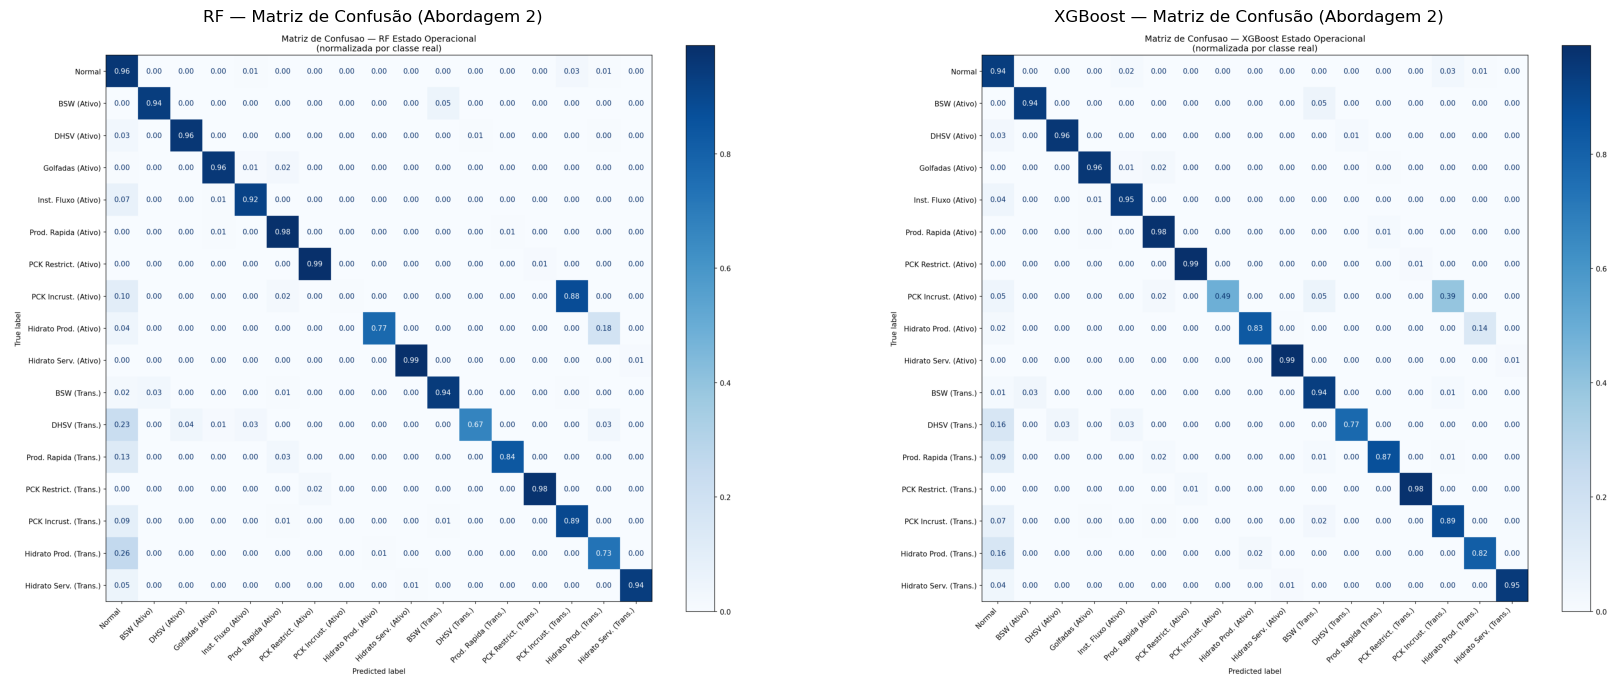

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].imshow(mpimg.imread(str(FIG_CM / "confusion_matrix_rf_estado_operacional.png")))
axes[0].set_title("RF — Matriz de Confusão (Abordagem 2)", fontsize=12)
axes[0].axis("off")
axes[1].imshow(mpimg.imread(str(FIG_CM / "confusion_matrix_xgboost_estado_operacional.png")))
axes[1].set_title("XGBoost — Matriz de Confusão (Abordagem 2)", fontsize=12)
axes[1].axis("off")
plt.tight_layout()
plt.show()

---
## 8. Interpretabilidade — XAI

O modelo aprendeu os mecanismos físicos reais ou apenas padrões espúrios?

- **MDI:** importância nativa das árvores (rápida, mas enviesada para features contínuas)
- **SHAP:** teoria dos jogos — contribuição marginal e justa de cada feature por predição

> ⏳ Calculado sobre amostra balanceada: 50 janelas × 17 classes = 850 janelas.

Feature Importance MDI — Top 20 (RF vs XGBoost)


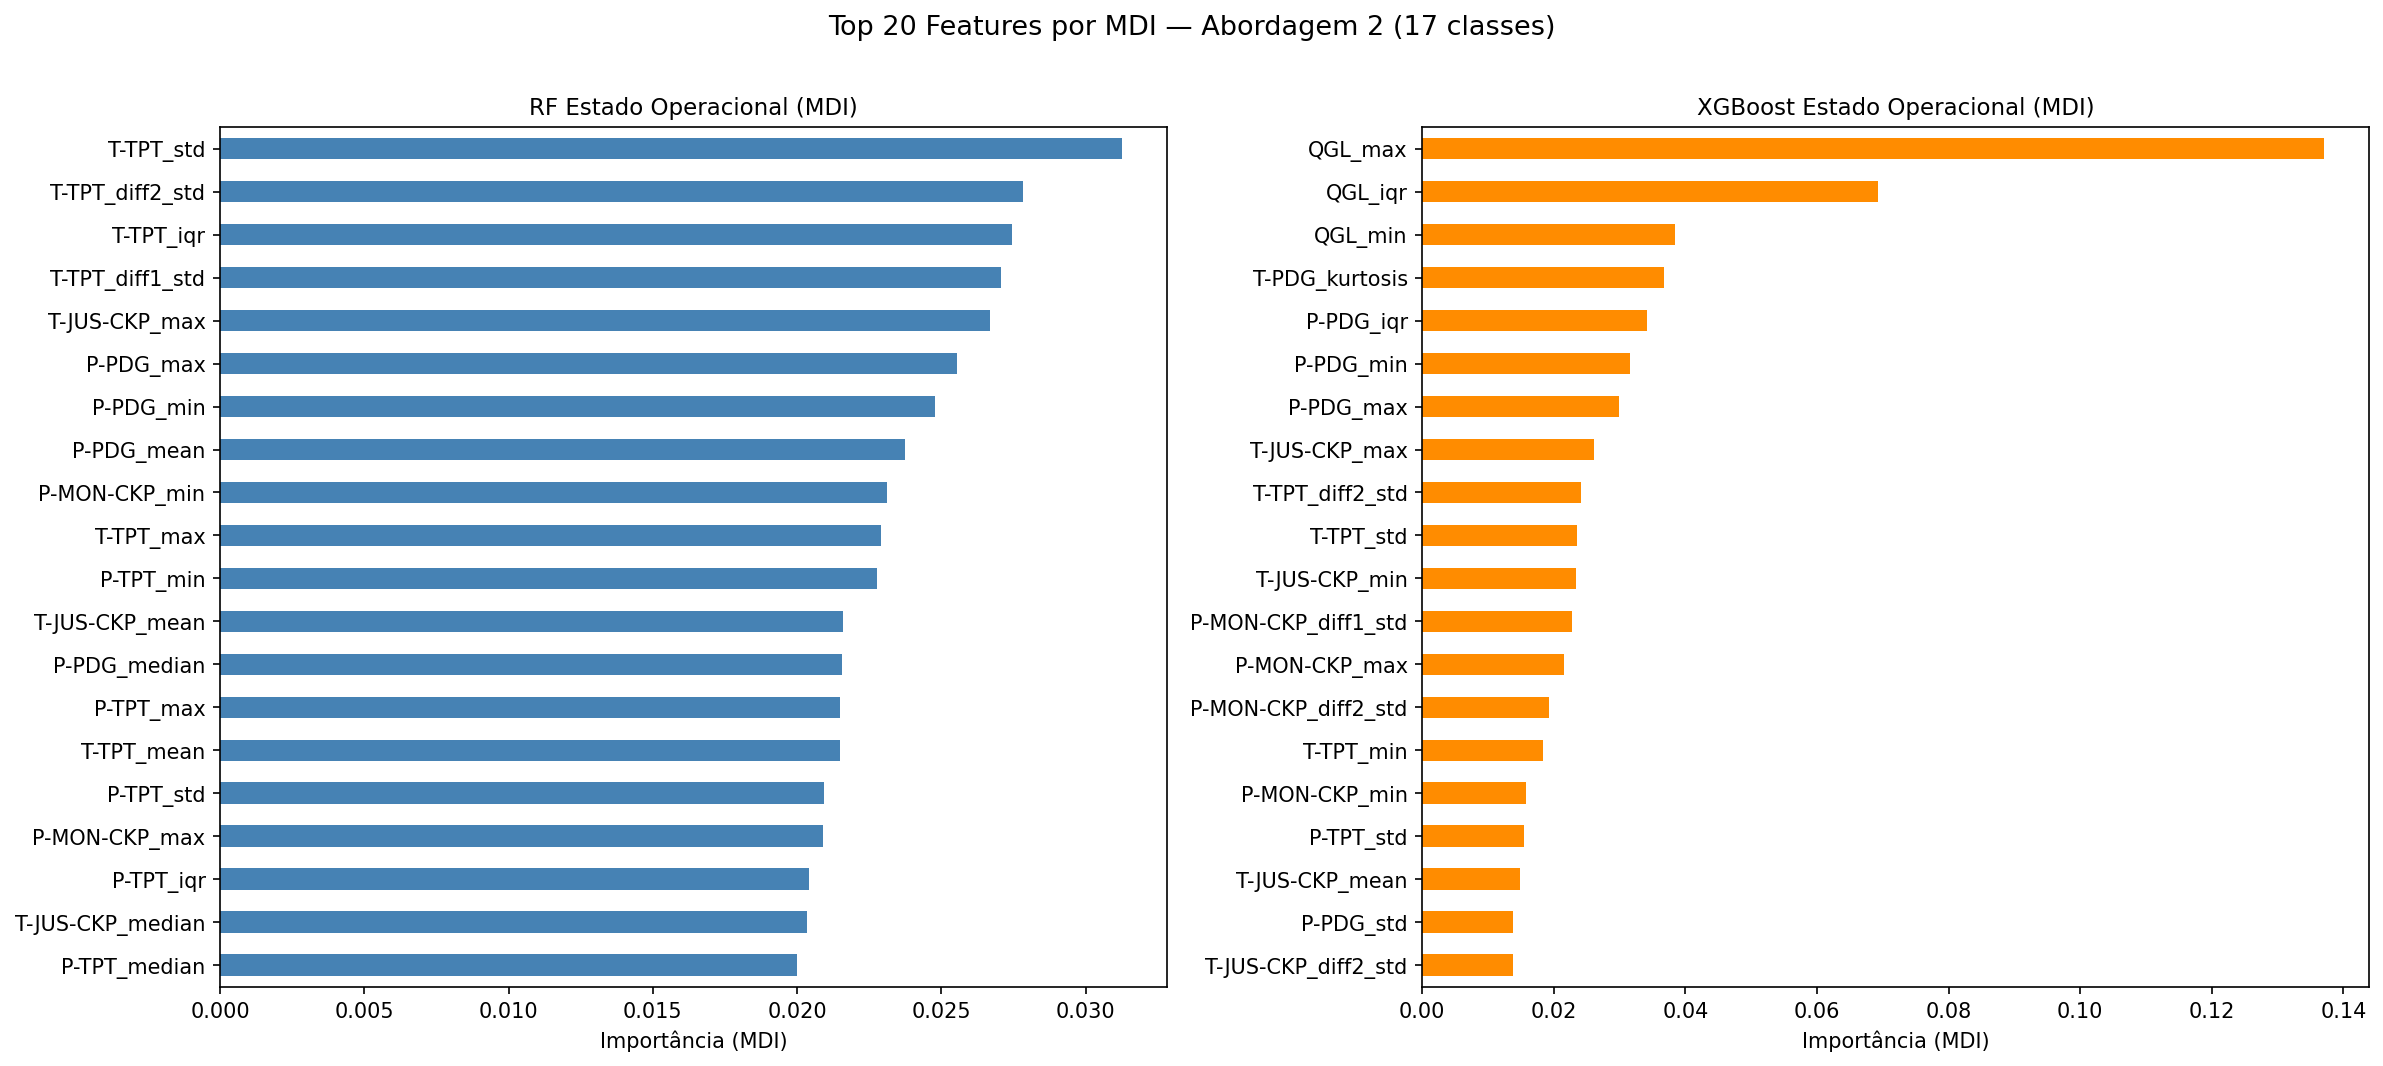

In [12]:
print("Feature Importance MDI — Top 20 (RF vs XGBoost)")
display(Image(str(FIG_SHAP / "mdi_rf_xgb_estado_operacional.png"), width=980))

SHAP Global — RF: T-TPT_std e T-TPT_iqr dominam
(temperatura no topo: variabilidade e spread do miolo dos dados)


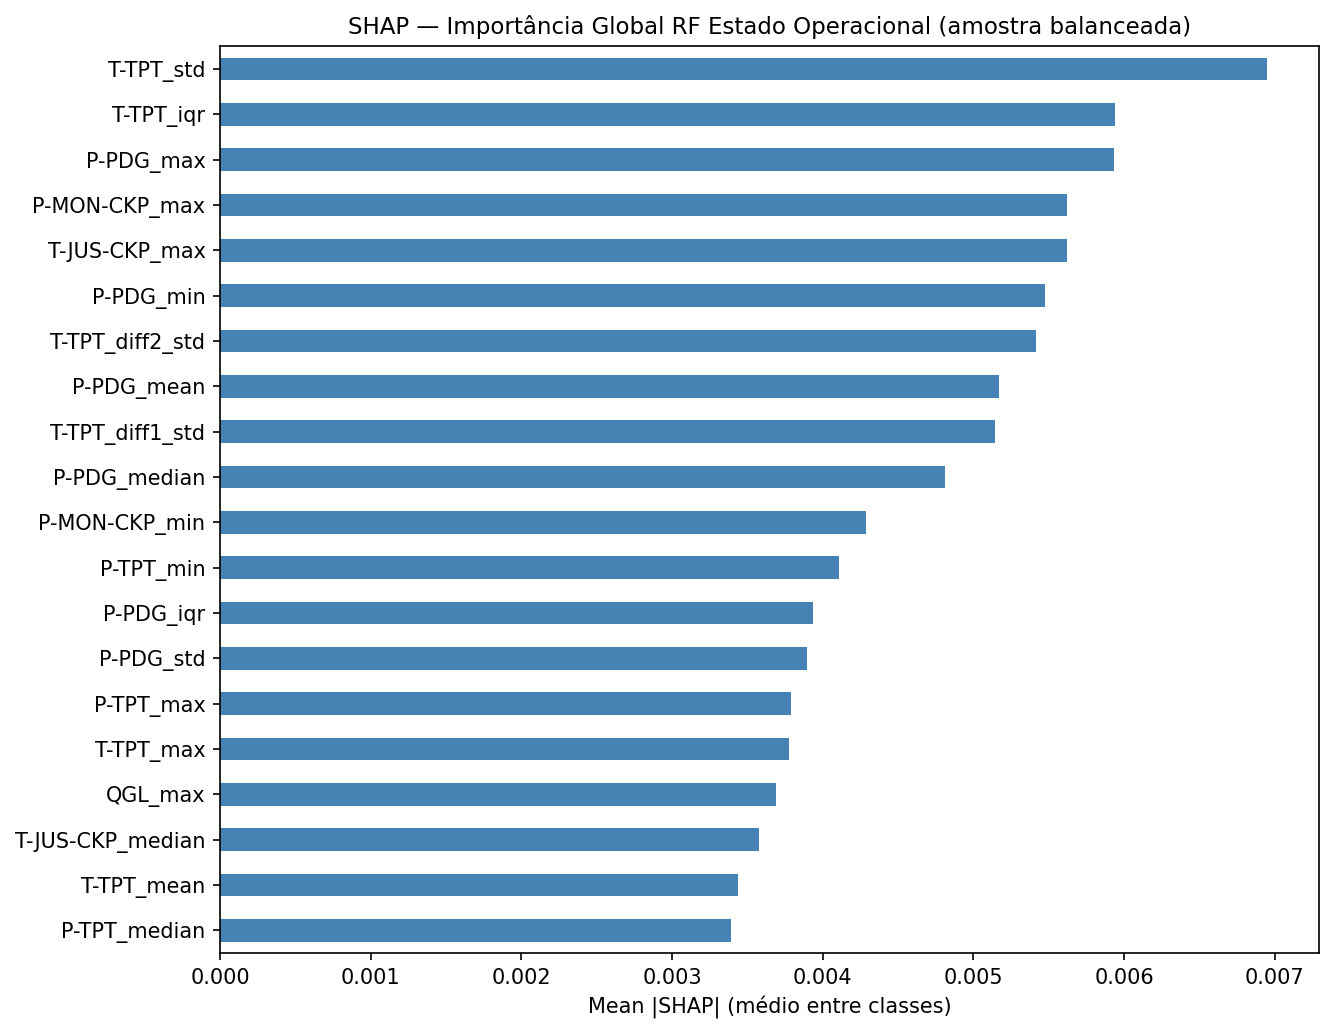

In [13]:
print("SHAP Global — RF: T-TPT_std e T-TPT_iqr dominam")
print("(temperatura no topo: variabilidade e spread do miolo dos dados)")
display(Image(str(FIG_SHAP / "shap_bar_rf_estado_operacional.png"), width=720))

Importância por Sensor — T-TPT lidera em ambos os modelos
T-PDG (temperatura no fundo) é o menos informativo: varia pouco entre estados


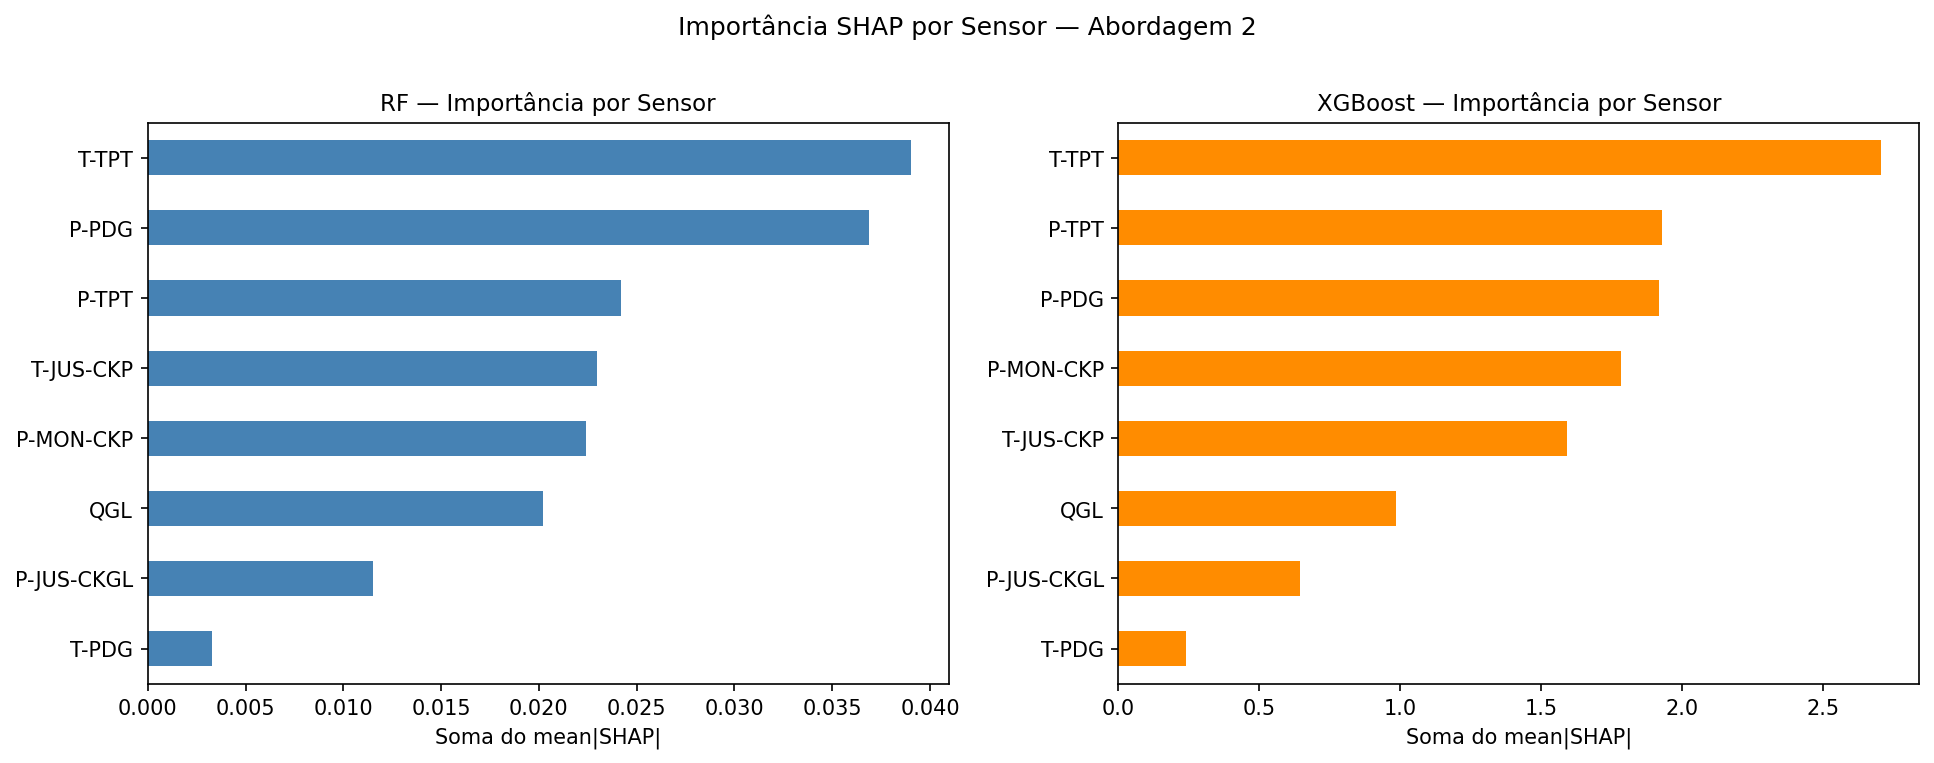

In [14]:
print("Importância por Sensor — T-TPT lidera em ambos os modelos")
print("T-PDG (temperatura no fundo) é o menos informativo: varia pouco entre estados")
display(Image(str(FIG_SHAP / "shap_por_sensor_estado_operacional.png"), width=980))

### 8.1 Classe 7 — PCK Incrustação Ativo (RF F1=0,009 | XGBoost F1=0,571)

Classe mais desbalanceada: **914 janelas em 449.397 (0,2%)**.

- **RF:** todos os SHAP values próximos de zero — o modelo nunca prediz a classe 7.
  O *bagging* paralelo dilui a minoria em cada bootstrap.
- **XGBoost:** valores SHAP de −4 a +3 — `T-JUS-CKP_max` e `P-MON-CKP_mean` sobem,
  refletindo a restrição de fluxo causada pela incrustação na válvula choke.

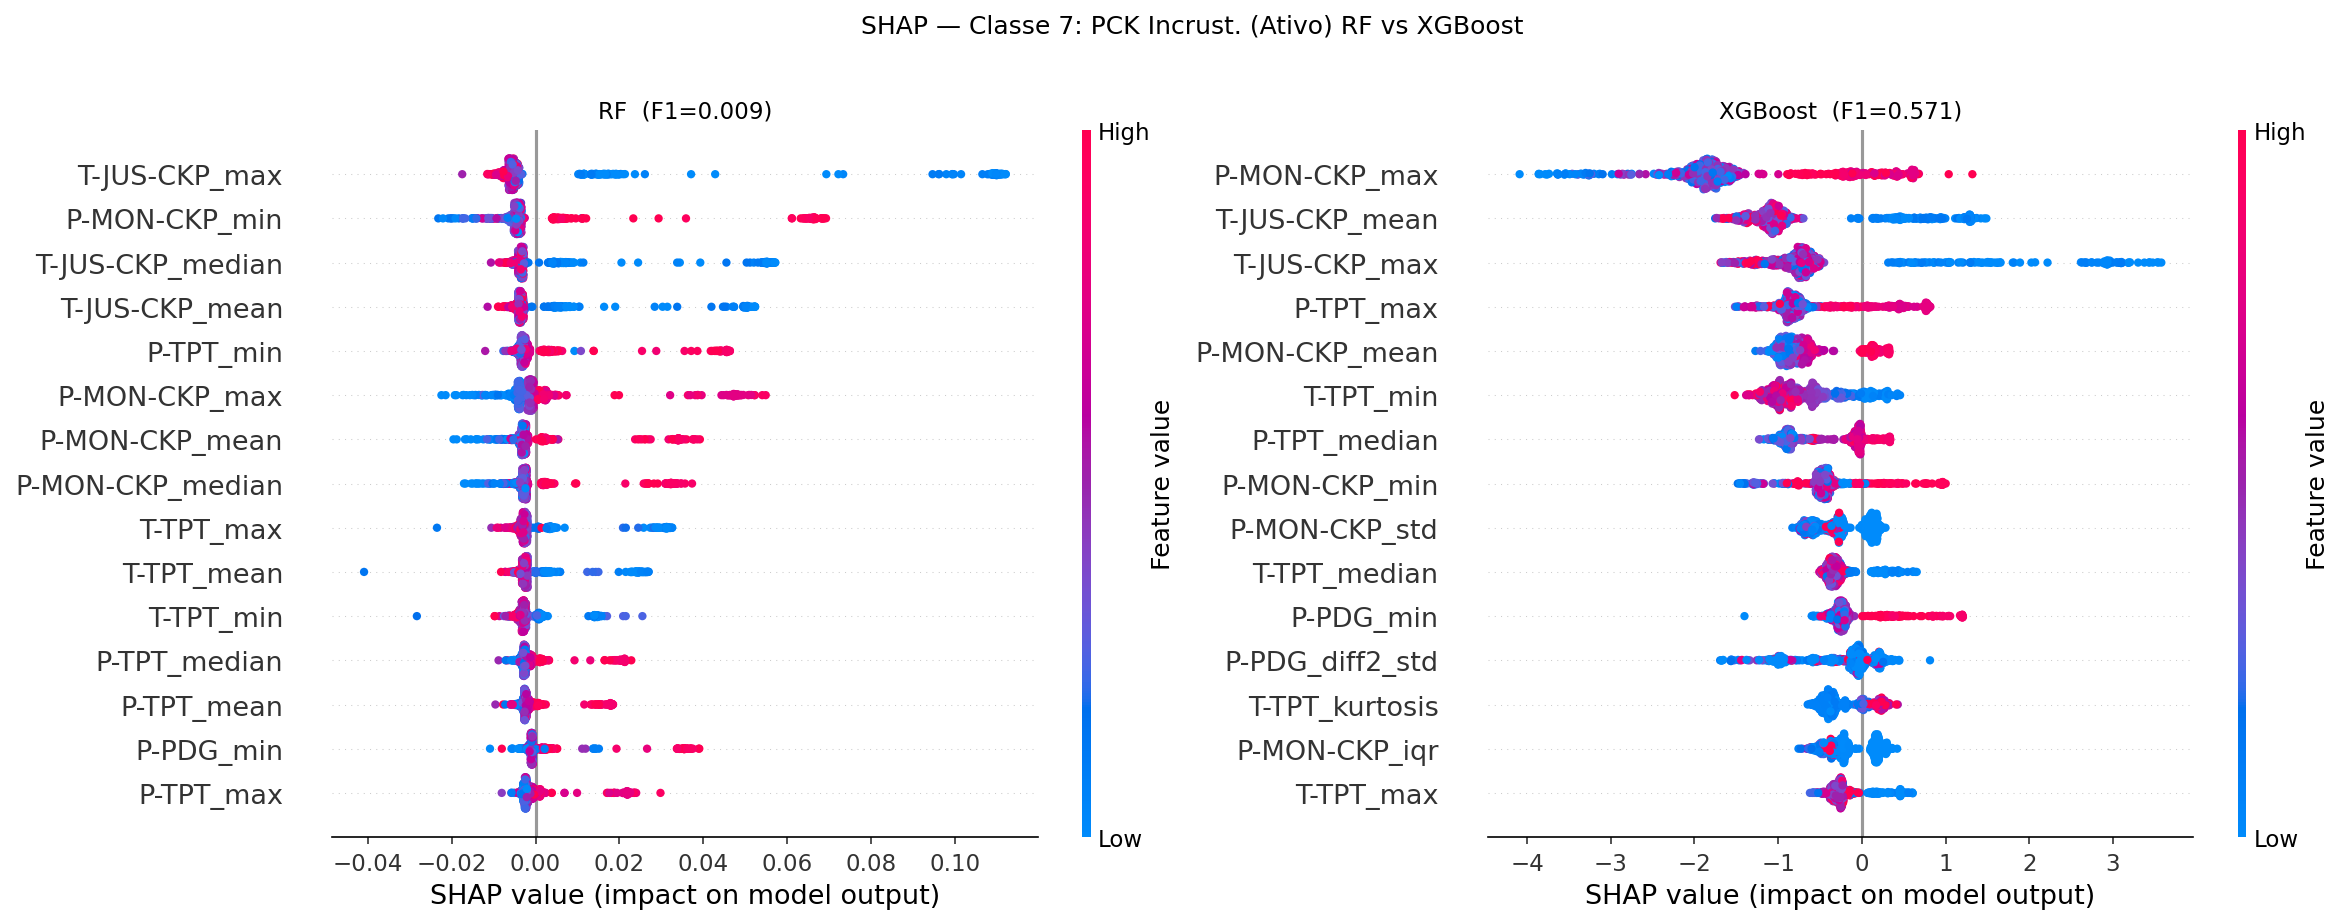

In [15]:
display(Image(str(FIG_SHAP / "shap_classe7_rf_vs_xgboost.png"), width=1060))

### 8.2 Classe 102 — DHSV Transiente (RF F1=0,786 | XGBoost F1=0,829)

O transiente é um estado **dinâmico** — a janela captura a *transição* do fechamento.
Features de taxa de variação (`diff1_std`) e forma (`skewness`, `iqr`) superam
features estáticas (`mean`, `max`) — o XGBoost captura essa dinâmica melhor.

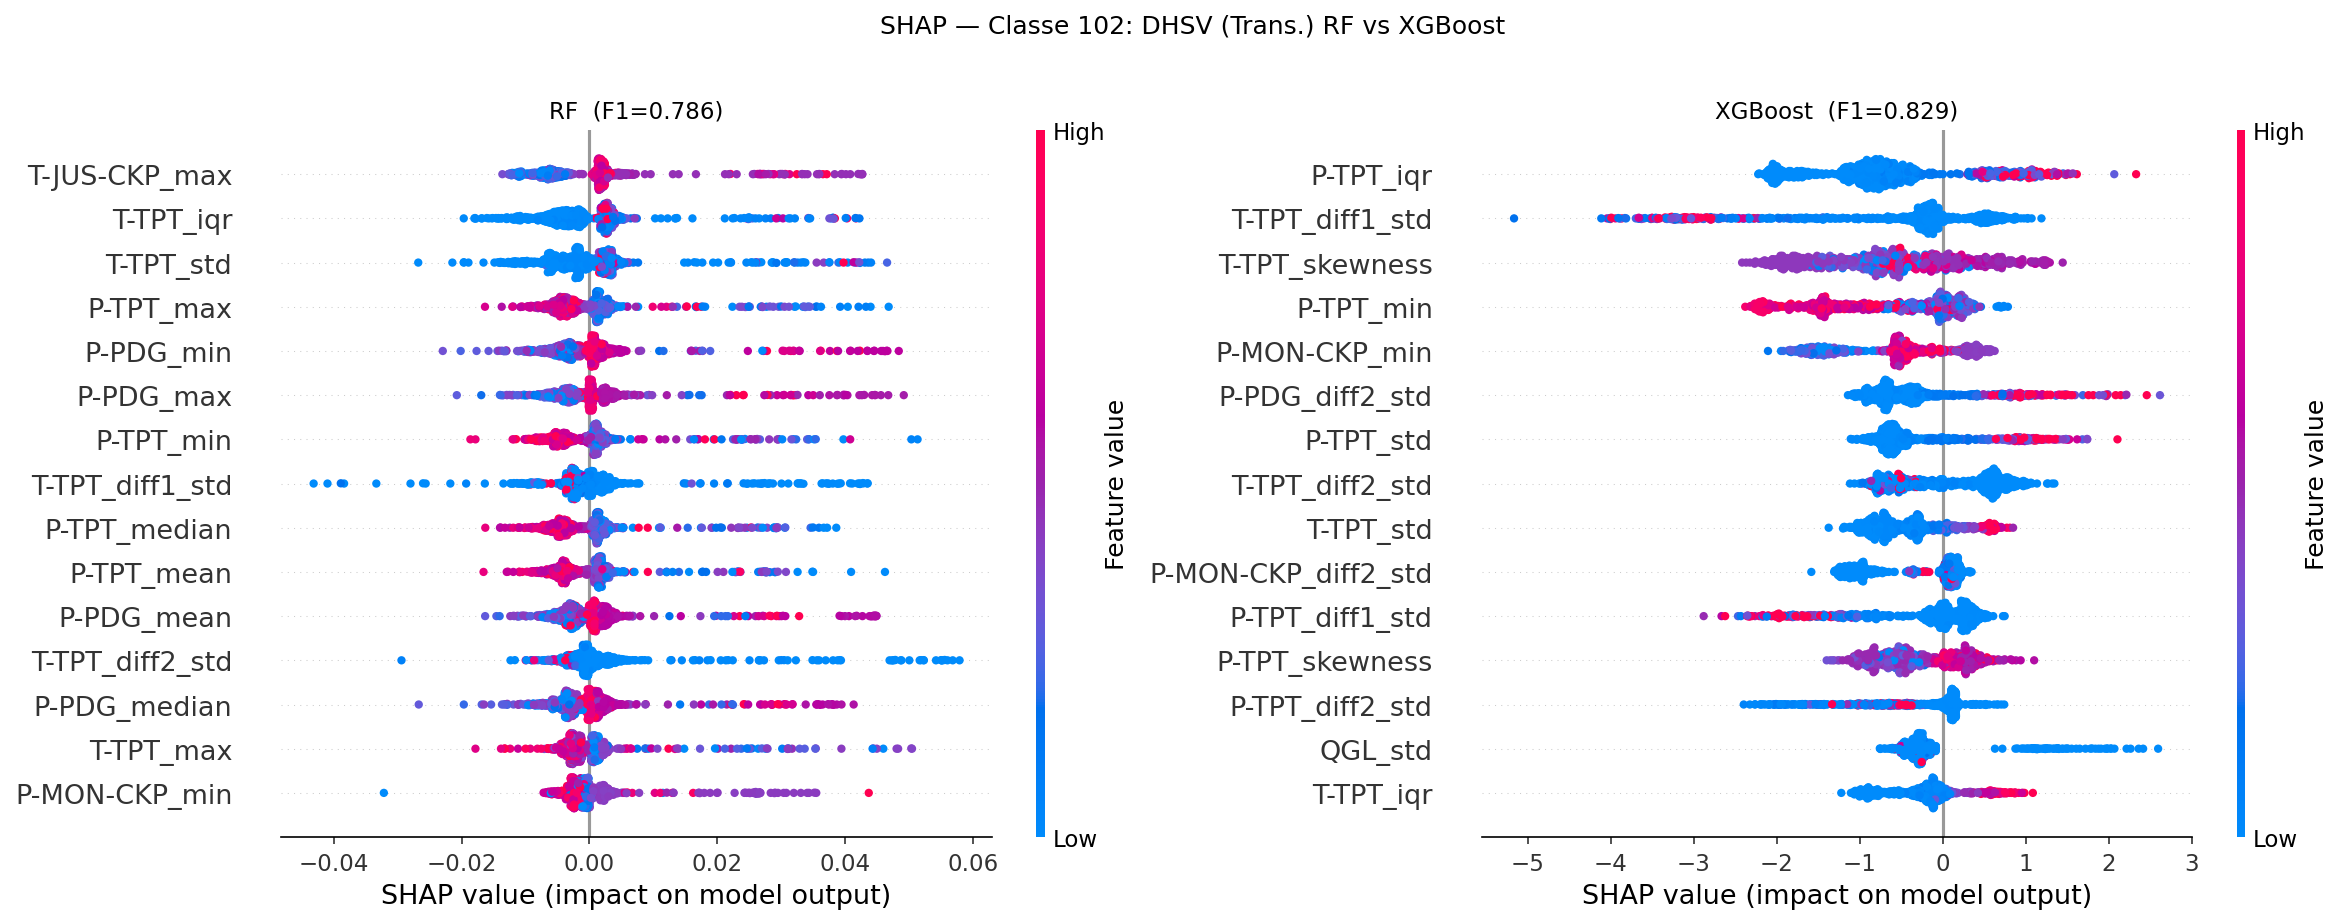

In [16]:
display(Image(str(FIG_SHAP / "shap_classe102_rf_vs_xgboost.png"), width=1060))

### 8.3 Classe 8 — Hidrato na Linha de Produção (RF F1=0,855 | XGBoost F1=0,850)

Ambos os modelos concordam. As features aprendidas mapeiam diretamente para
a termodinâmica de formação de hidratos:

| Feature | Direção | Física |
|---------|---------|--------|
| `T-JUS-CKP_min` baixo | → classe 8 | Temperatura abaixo da curva de equilíbrio a jusante do choke (efeito Joule-Thomson) |
| `P-MON-CKP_max` alto | → classe 8 | Alta pressão favorece formação de hidratos |
| `P-TPT_iqr` alto | → classe 8 | Tampão de hidrato gera bloqueio intermitente → pulsos de pressão |

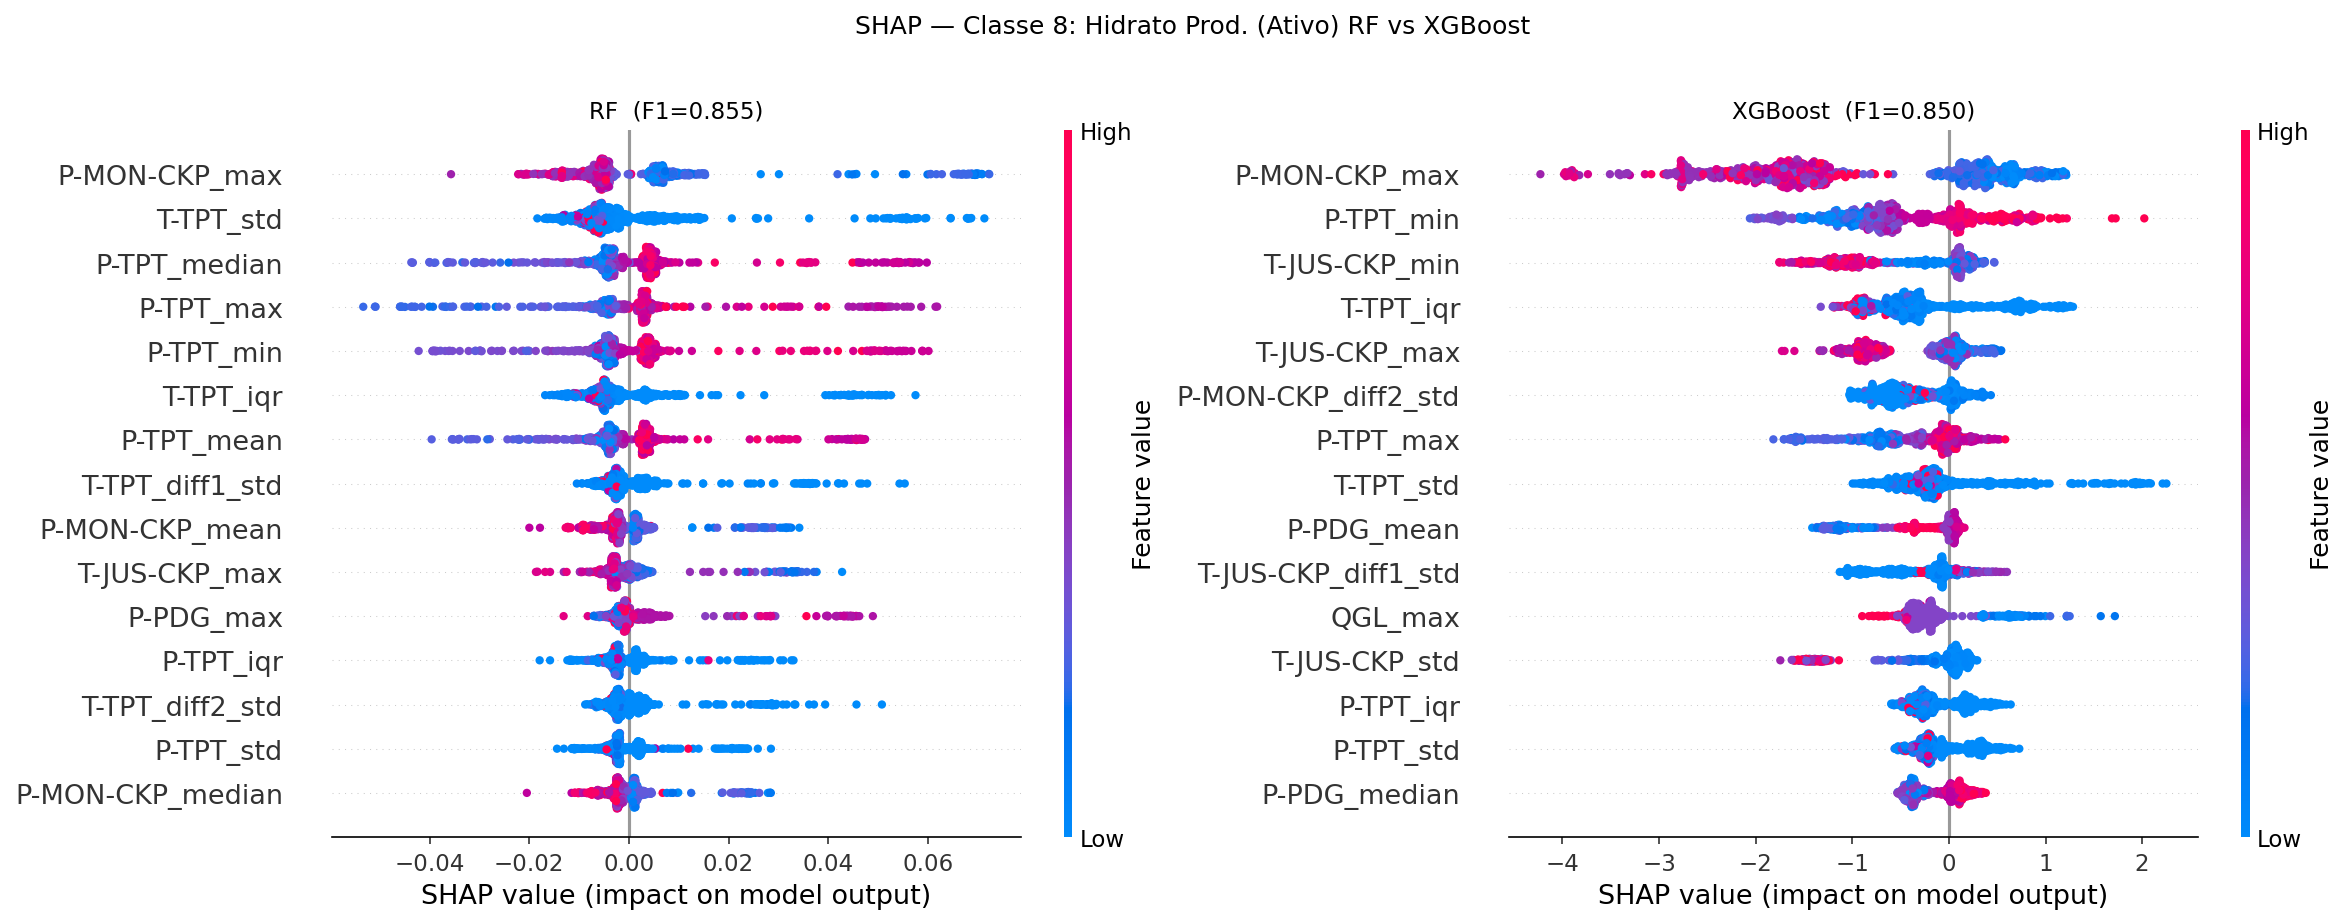

In [17]:
display(Image(str(FIG_SHAP / "shap_classe8_rf_vs_xgboost.png"), width=1060))

---
## 9. Conclusões

### Desempenho (Abordagem 2 — 17 classes, Estado Operacional)

| Modelo | F1-macro | Accuracy | Validação (Nested CV) |
|--------|:--------:|:--------:|:---------------------:|
| Random Forest | 0,872 | 0,932 | 0,873 ± 0,020 |
| **XGBoost** | **0,908** | **0,936** | — |

O XGBoost supera o RF em todas as métricas, com ganho mais expressivo nas classes
desbalanceadas (Classe 7: RF F1=0,009 → XGBoost F1=0,571).

### O modelo aprendeu física?

A análise SHAP confirma que sim:

1. **T-TPT** é o sensor mais informativo — temperatura no topo reflete mudanças de fluxo
   que antecedem ou acompanham todos os eventos
2. **Features dinâmicas** (`diff1_std`, `skewness`) superam estáticas para transientes
3. **XGBoost detecta classes raras** via boosting — foco progressivo em erros residuais
4. **Hidrato:** `T-JUS-CKP_min` baixo + `P-MON-CKP_max` alto reproduzem as condições
   termodinâmicas exatas de formação de hidratos na linha de produção

### Limitações e próximos passos

- Classe 7 (PCK Incrustação) ainda com F1=0,571 — abaixo do ideal para uso operacional
- MLP a ser avaliado — pode capturar interações não-lineares adicionais
- Augmentação de dados sintéticos específicos para classe 7 como trabalho futuro